# Preparação dos dados — Brent crude oil

**Projeto:** O Preço da Guerra — Visualização do impacto da guerra Irão–EUA (Fev 2026) em Portugal
**Autor:** Luis Miguel Pereira Silva · PG60390
**Universidade:** Universidade do Minho — Mestrado em Inteligência Artificial
**Disciplina:** Sistemas de Visualização de Dados e Conhecimento (SVDC)

---

## Fonte

[Federal Reserve Bank of St. Louis — FRED](https://fred.stlouisfed.org/series/DCOILBRENTEU) 
Série **DCOILBRENTEU** — *Crude Oil Prices: Brent - Europe* (USD por barril, frequência diária).

Ficheiro original: `data/DCOILBRENTEU.csv` (descarregado a 3 maio 2026)
Ficheiro produzido: `data/brent_daily.csv`

## Porque é importante

O Brent é a referência global do preço do petróleo. Quando o Estreito de Ormuz fica ameaçado, 
o preço do Brent reage **antes** dos preços dos combustíveis em Portugal — é o nosso *leading indicator*.
Vamos usar esta série na **Secção IV** do storytelling, sobreposta com o gasóleo PT.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')


## 1. Carregar o ficheiro original


In [2]:
raw = pd.read_csv(RAW / 'DCOILBRENTEU.csv')
print('Shape:', raw.shape)
print('Tipos:', raw.dtypes.to_dict())
raw.head()


Shape: (1305, 2)
Tipos: {'observation_date': dtype('O'), 'DCOILBRENTEU': dtype('float64')}


,observation_date,DCOILBRENTEU
0,2021-04-27,66.25
1,2021-04-28,67.08
2,2021-04-29,68.26
3,2021-04-30,67.73
4,2021-05-03,NaN


## 2. Limpeza

O CSV do FRED já vem bastante limpo. Apenas precisamos de:

1. Converter a coluna `observation_date` para `datetime`
2. Tratar valores em falta (a FRED usa `.` ou strings vazias em feriados)
3. Validar o intervalo temporal


In [3]:
df = raw.copy()
df['observation_date'] = pd.to_datetime(df['observation_date'])

# Forçar coluna numérica — strings ('.', '') viram NaN
df['DCOILBRENTEU'] = pd.to_numeric(df['DCOILBRENTEU'], errors='coerce')

print(f'Período: {df.observation_date.min().date()} → {df.observation_date.max().date()}')
print(f'Linhas com valor: {df.DCOILBRENTEU.notna().sum()} / {len(df)}')
print(f'Valores em falta: {df.DCOILBRENTEU.isna().sum()} (feriados / fim-de-semana)')


Período: 2021-04-27 → 2026-04-27
Linhas com valor: 1264 / 1305
Valores em falta: 41 (feriados / fim-de-semana)


## 3. Inspeção visual rápida

Confirmar a forma da série — em particular o salto após 28 fev 2026.


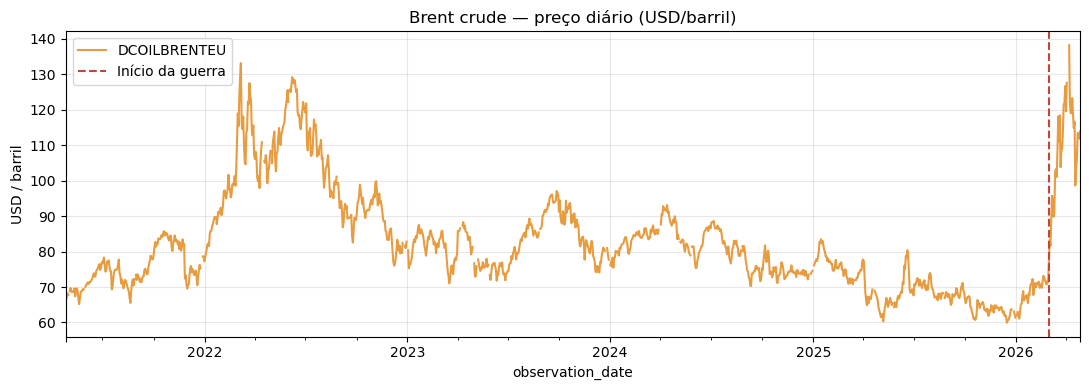

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
df.set_index('observation_date')['DCOILBRENTEU'].plot(ax=ax, color='#e89c3f')
ax.axvline(pd.Timestamp('2026-02-28'), color='#c44536', linestyle='--', label='Início da guerra')
ax.set_title('Brent crude — preço diário (USD/barril)')
ax.set_ylabel('USD / barril')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Métricas-chave para o storytelling

Antes de exportar, calcular os números que aparecem no hero do site ("+60% Brent").


In [5]:
pre_war  = df[(df.observation_date >= '2026-02-01') & (df.observation_date < '2026-02-28')]['DCOILBRENTEU'].mean()
post_war = df[df.observation_date >= '2026-03-01']['DCOILBRENTEU'].mean()
delta_pct = (post_war - pre_war) / pre_war * 100

print(f'Brent médio Fev 2026 (pré-guerra) : ${pre_war:.1f}')
print(f'Brent médio Mar–Abr 2026 (pós)   : ${post_war:.1f}')
print(f'Variação                          : {delta_pct:+.1f} %')


Brent médio Fev 2026 (pré-guerra) : $70.9
Brent médio Mar–Abr 2026 (pós)   : $108.9
Variação                          : +53.7 %


## 5. Exportar o CSV limpo

Mantemos o mesmo schema do FRED (`observation_date`, `DCOILBRENTEU`) — assim não temos de mexer no `js/main.js`.


In [6]:
out = PROCESSED / 'brent_daily.csv'
df.to_csv(out, index=False)
print('✓ Gravado em', out)
print(f'  ({len(df)} linhas, {df.DCOILBRENTEU.notna().sum()} com valor)')


✓ Gravado em ..\data\brent_daily.csv
  (1305 linhas, 1264 com valor)


---

## ✓ Resultado

`data/brent_daily.csv` está pronto para ser carregado pelo `drawPrices()` em `js/main.js`.
Próximo notebook: **prep_combustiveis.ipynb** — preços do gasóleo e gasolina em Portugal.
